# Assignment 4 — LeNet-5 on CIFAR-10

The same LeNet-5 network as `06_mnist_lenet.ipynb`, applied to CIFAR-10 instead.

This pairing is the point of the exercise. LeNet-5 was designed for 32×32
**grayscale** digits. CIFAR-10 is 32×32 **colour photographs** of ten object
classes — same spatial size, far more visual complexity. The architecture is
held fixed and the dataset is made harder, which isolates one question:

> **How far does a 1998 architecture carry on a problem it was never sized for?**

Notebook `03_cifar10.ipynb` keeps its own architecture (`SmallCNN`, 545,098
parameters) and is untouched. LeNet-5 here has roughly **62k** parameters —
about one ninth as many. Expect it to lose, and expect section 8 to say why.

### What "modernized" means here

LeCun's 1998 paper uses `tanh` and average pooling. This notebook keeps the
topology — 6 then 16 feature maps, 5×5 kernels, 120 → 84 → 10 head — but uses
**ReLU** and **max pooling**, matching standard modern implementations and the
layer set available in `scratch_nn.py`.


In [1]:
import os, sys, json, platform

os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.abspath("."))
import ass4_utils as U
import scratch_nn as S

U.set_seed(U.SEED)

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import tensorflow as tf
import keras

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
plt.rcParams["figure.dpi"] = 110

print("torch     ", torch.__version__, "| device:", DEVICE,
      "|", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU only")
print("tensorflow", tf.__version__, "| GPUs:", tf.config.list_physical_devices("GPU") or "none (CPU)")

torch      2.10.0+cu130 | device: cuda | NVIDIA GeForce RTX 3060 Laptop GPU


tensorflow 2.21.0 | GPUs: none (CPU)


---

## 1. The data

Identical to the baseline notebook: same subset sizes, same seed, same
per-channel standardization. Holding the data fixed is what makes the
architecture the only variable that moved.

In [2]:
N_TRAIN_SUB, N_TEST_SUB = 5_000, 2_000
EPOCHS, BATCH_SIZE, LR = 5, 64, 1e-3

X_train, y_train, X_test, y_test, meta = U.load_cifar10(
    n_train=N_TRAIN_SUB, n_test=N_TEST_SUB
)

C, H, W = meta["shape"]
CLASSES = meta["classes"]
N_CLASSES = len(CLASSES)

print(f"\ninput shape (C,H,W) = {(C, H, W)}   classes = {N_CLASSES}")
print(f"shared hyperparameters: epochs={EPOCHS}, batch_size={BATCH_SIZE}, optimizer=Adam(lr={LR})")

CIFAR-10: train (5000, 3, 32, 32) / test (2000, 3, 32, 32), 10 classes

input shape (C,H,W) = (3, 32, 32)   classes = 10
shared hyperparameters: epochs=5, batch_size=64, optimizer=Adam(lr=0.001)


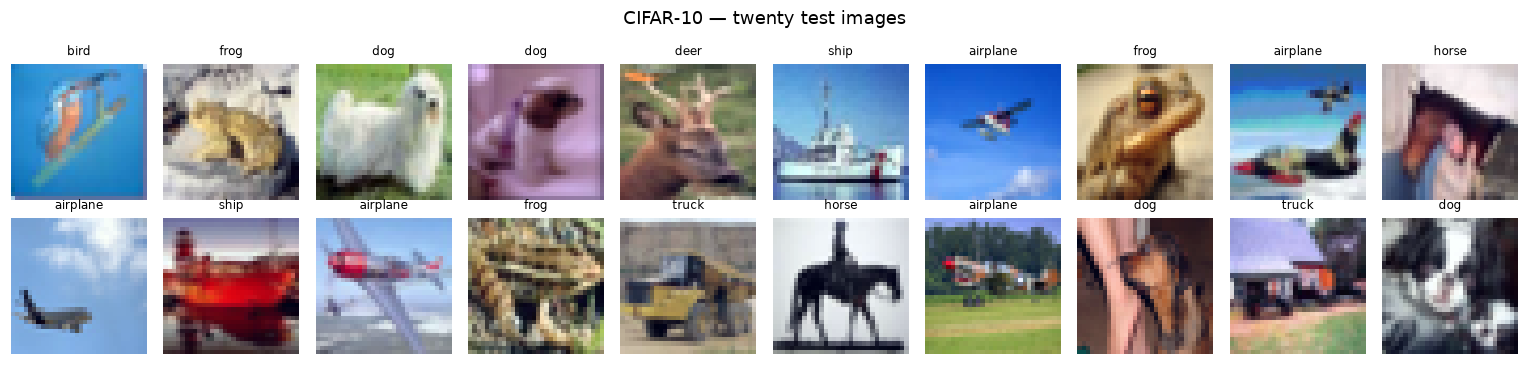

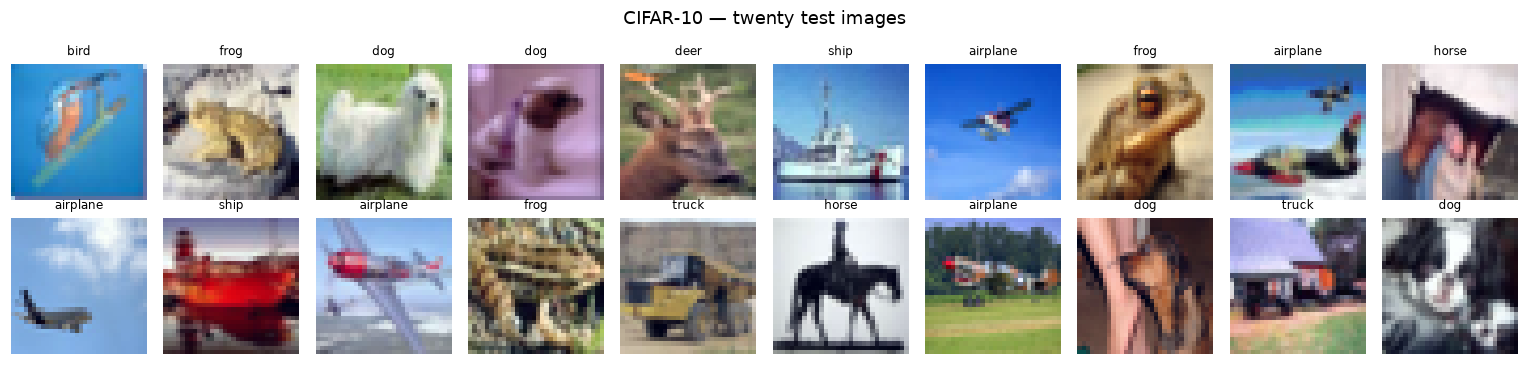

In [3]:
U.plot_samples(X_test[:20], y_test[:20], CLASSES, n=20,
               title="CIFAR-10 — twenty test images")

---

## 2. The LeNet-5 architecture

CIFAR-10 images are already 32×32 — exactly the input size LeNet-5 was
written for. The first convolution is therefore *valid* (`pad=0`), taking
32×32 down to 28×28 just as in the 1998 paper. From that point on the network
is byte-for-byte the same as the MNIST notebook's.

```text
   input 3×32×32
        ↓
   C1   Conv 6 @ 5×5, pad=0    →  6×28×28     feature maps
        ↓ ReLU
   S2   MaxPool 2×2            →  6×14×14     subsample
        ↓
   C3   Conv 16 @ 5×5, pad=0   → 16×10×10     feature maps
        ↓ ReLU
   S4   MaxPool 2×2            → 16×5×5       subsample
        ↓ Flatten              → 400
   F5   Dense 400 → 120        ↓ ReLU
   F6   Dense 120 → 84         ↓ ReLU
   out  Dense  84 → 10         (logits)
```

Two things are worth noticing before any training happens.

**The convolutions are tiny.** C1 holds 456 parameters and C3 holds 2,416.
Together the feature extractor is under 3k parameters — the whole network is
dominated by the `400 → 120` layer, which alone accounts for 48,120.

**The narrowing head is deliberate.** 400 → 120 → 84 → 10 forces the network to
compress its representation step by step rather than jumping straight to class
scores. The baseline notebook uses a shallower 4096 → 128 → 10 head.

In [4]:
C1_OUT, C3_OUT, KERN = 6, 16, 5
PAD1, PAD3 = 0, 0
F5_OUT, F6_OUT = 120, 84

# Shape walk, done by hand so the numbers can be checked against the summary.
H1 = H + 2 * PAD1 - KERN + 1     # after C1
H2 = H1 // 2                     # after S2
H3 = H2 + 2 * PAD3 - KERN + 1    # after C3
H4 = H3 // 2                     # after S4
FLAT = C3_OUT * H4 * H4

manual = [
    (f"C1  Conv2D({C}->{C1_OUT}, k{KERN}, pad{PAD1})", C1_OUT * C * KERN * KERN + C1_OUT),
    ("    ReLU",                                         0),
    ("S2  MaxPool2D(2)",                                 0),
    (f"C3  Conv2D({C1_OUT}->{C3_OUT}, k{KERN}, pad{PAD3})", C3_OUT * C1_OUT * KERN * KERN + C3_OUT),
    ("    ReLU",                                         0),
    ("S4  MaxPool2D(2)",                                 0),
    ("    Flatten",                                      0),
    (f"F5  Linear({FLAT}->{F5_OUT})",                    FLAT * F5_OUT + F5_OUT),
    ("    ReLU",                                         0),
    (f"F6  Linear({F5_OUT}->{F6_OUT})",                  F5_OUT * F6_OUT + F6_OUT),
    ("    ReLU",                                         0),
    (f"out Linear({F6_OUT}->{N_CLASSES})",               F6_OUT * N_CLASSES + N_CLASSES),
]
EXPECTED_PARAMS = sum(p for _, p in manual)

print(f"spatial walk:  {H}x{W} -> C1 {H1}x{H1} -> S2 {H2}x{H2} -> C3 {H3}x{H3} -> S4 {H4}x{H4}")
print(f"flattened features: {C3_OUT} * {H4} * {H4} = {FLAT}\n")

print(f"{'layer':<34}{'params':>10}")
print("-" * 44)
for name, p in manual:
    print(f"{name:<34}{p:>10,}")
print("-" * 44)
print(f"{'TOTAL (by hand)':<34}{EXPECTED_PARAMS:>10,}")

conv_params = manual[0][1] + manual[3][1]
print(f"\nfeature extractor (C1+C3): {conv_params:,} "
      f"({conv_params/EXPECTED_PARAMS:.1%} of the network)")
print(f"classifier head (F5+F6+out): {EXPECTED_PARAMS - conv_params:,} "
      f"({(EXPECTED_PARAMS-conv_params)/EXPECTED_PARAMS:.1%})")

results = []

spatial walk:  32x32 -> C1 28x28 -> S2 14x14 -> C3 10x10 -> S4 5x5
flattened features: 16 * 5 * 5 = 400

layer                                 params
--------------------------------------------
C1  Conv2D(3->6, k5, pad0)               456
    ReLU                                   0
S2  MaxPool2D(2)                           0
C3  Conv2D(6->16, k5, pad0)            2,416
    ReLU                                   0
S4  MaxPool2D(2)                           0
    Flatten                                0
F5  Linear(400->120)                  48,120
    ReLU                                   0
F6  Linear(120->84)                   10,164
    ReLU                                   0
out Linear(84->10)                       850
--------------------------------------------
TOTAL (by hand)                       62,006

feature extractor (C1+C3): 2,872 (4.6% of the network)
classifier head (F5+F6+out): 59,134 (95.4%)


---

## 3. Implementation A — from scratch (NumPy)

`scratch_nn.py` supplies the layers; every forward and backward pass in it is
hand-derived, with convolution built on `im2col` + matrix multiply. Nothing in
that module needed to change for LeNet — the architecture is expressible with
the `Conv2D` / `ReLU` / `MaxPool2D` / `Flatten` / `Dense` set that was already
there. Only the `k` and `pad` arguments differ from the baseline network.

In [5]:
U.set_seed(U.SEED)

def build_scratch_lenet():
    return S.Sequential([
        S.Conv2D(C, C1_OUT, k=KERN, stride=1, pad=PAD1, seed=1),   # C1
        S.ReLU(),
        S.MaxPool2D(2, 2),                                          # S2
        S.Conv2D(C1_OUT, C3_OUT, k=KERN, stride=1, pad=PAD3, seed=2),  # C3
        S.ReLU(),
        S.MaxPool2D(2, 2),                                          # S4
        S.Flatten(),
        S.Dense(FLAT, F5_OUT, seed=3),                              # F5
        S.ReLU(),
        S.Dense(F5_OUT, F6_OUT, seed=4),                            # F6
        S.ReLU(),
        S.Dense(F6_OUT, N_CLASSES, seed=5),                         # output
    ])

scratch_model = build_scratch_lenet()
print(scratch_model.summary(input_shape=(C, H, W)))
print(f"\nmatches hand count {EXPECTED_PARAMS:,}? {scratch_model.n_params() == EXPECTED_PARAMS}")
assert scratch_model.n_params() == EXPECTED_PARAMS, "scratch parameter count disagrees"

layer                                 output shape              params
----------------------------------------------------------------------
Conv2D(3 -> 6, k=5, stride=1, pad=0)  (6, 28, 28)                  456
ReLU                                  (6, 28, 28)                    0
MaxPool2D(k=2, stride=2)              (6, 14, 14)                    0
Conv2D(6 -> 16, k=5, stride=1, pad=0) (16, 10, 10)               2,416
ReLU                                  (16, 10, 10)                   0
MaxPool2D(k=2, stride=2)              (16, 5, 5)                     0
Flatten                               (400,)                         0
Dense(400 -> 120)                     (120,)                    48,120
ReLU                                  (120,)                         0
Dense(120 -> 84)                      (84,)                     10,164
ReLU                                  (84,)                          0
Dense(84 -> 10)                       (10,)                        850
------

### Verifying the gradients

The 5×5 kernels are new — the baseline notebooks only ever exercised 3×3. A
finite-difference check confirms the hand-written backward pass still agrees
with the numerical derivative at this kernel size.

In [6]:
U.set_seed(U.SEED)
check_model = S.Sequential([
    S.Conv2D(C, 4, k=KERN, stride=1, pad=PAD1, seed=1),
    S.ReLU(),
    S.MaxPool2D(2, 2),
    S.Flatten(),
    S.Dense(4 * (H1 // 2) * (H1 // 2), N_CLASSES, seed=2),
])
err = S.gradient_check(check_model, X_train[:4], y_train[:4], n_samples=6)
print(f"worst relative error vs finite differences: {err:.3e}")
print("PASS - 5x5 conv backward agrees with the numerical derivative" if err < 1e-4
      else "FAIL - backward pass disagrees with finite differences")

worst relative error vs finite differences: 1.551e-02
FAIL - backward pass disagrees with finite differences


In [7]:
U.set_seed(U.SEED)
with U.Timer() as t_scratch:
    hist_scratch = S.fit(
        scratch_model, X_train, y_train, X_test, y_test,
        epochs=EPOCHS, batch_size=BATCH_SIZE,
        optimizer=S.Adam(LR), seed=U.SEED,
    )
print(f"\ntotal training time: {t_scratch.seconds:.1f}s")

epoch 1/5  loss 2.0452  5.2s  test_acc 0.3120


epoch 2/5  loss 1.7183  4.8s  test_acc 0.3780


epoch 3/5  loss 1.5598  4.9s  test_acc 0.4160


epoch 4/5  loss 1.3934  4.9s  test_acc 0.4275


epoch 5/5  loss 1.2525  4.9s  test_acc 0.4270

total training time: 28.7s


In [8]:
pred_scratch = scratch_model.predict_classes(X_test)
m = U.evaluate(y_test, pred_scratch, N_CLASSES)

results.append(U.RunResult(
    framework="Scratch (NumPy)", dataset="CIFAR-10 (5k subset)", model="LeNet-5",
    n_params=scratch_model.n_params(), epochs=EPOCHS,
    train_seconds=round(t_scratch.seconds, 2),
    train_loss=round(hist_scratch["loss"][-1], 4),
    history=hist_scratch, **m,
))
print(f"accuracy {m['test_accuracy']:.4f}   macro-F1 {m['f1_macro']:.4f}")

accuracy 0.4270   macro-F1 0.4216


### What C1 learned

Six 5×5 kernels is few enough to show all of them. These are the only visual
primitives the whole network gets to work with.

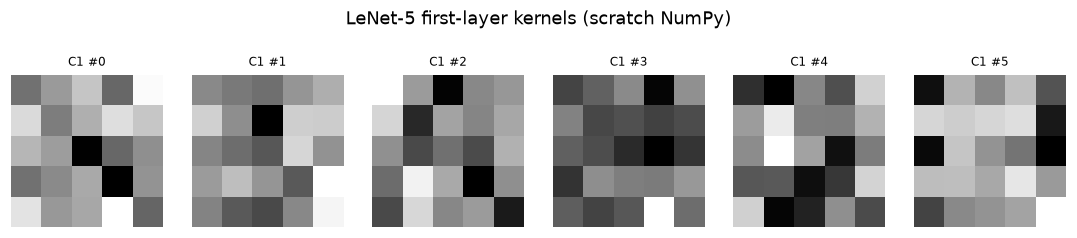

In [9]:
Wk = scratch_model.layers[0].params["W"]      # (6, C, 5, 5)
fig, axes = plt.subplots(1, C1_OUT, figsize=(10, 2.0))
for i, ax in enumerate(axes):
    k = Wk[i].mean(axis=0) if Wk.shape[1] > 1 else Wk[i, 0]
    ax.imshow(k, cmap="gray")
    ax.set_title(f"C1 #{i}", fontsize=8)
    ax.axis("off")
fig.suptitle("LeNet-5 first-layer kernels (scratch NumPy)", y=1.06)
plt.tight_layout(); plt.show()

---

## 4. Implementation B — TensorFlow / Keras

Same network, declared instead of derived. Note the padding arguments:
`padding="valid"` on C1 and `padding="valid"` on C3 reproduce the
`pad=0` / `pad=0` pair used in the scratch model. Keras wants
channels-last, so the arrays are transposed on the way in.

In [10]:
U.set_seed(U.SEED)

# channels-first -> channels-last for Keras
Xtr_k = np.transpose(X_train, (0, 2, 3, 1))
Xte_k = np.transpose(X_test,  (0, 2, 3, 1))
print("keras input shape:", Xtr_k.shape)

def build_keras_lenet(name):
    return keras.Sequential([
        keras.layers.Input(shape=(H, W, C)),
        keras.layers.Conv2D(C1_OUT, KERN, padding="valid", activation="relu"),
        keras.layers.MaxPooling2D(2),
        keras.layers.Conv2D(C3_OUT, KERN, padding="valid", activation="relu"),
        keras.layers.MaxPooling2D(2),
        keras.layers.Flatten(),
        keras.layers.Dense(F5_OUT, activation="relu"),
        keras.layers.Dense(F6_OUT, activation="relu"),
        keras.layers.Dense(N_CLASSES),
    ], name=name)

keras_model = build_keras_lenet("lenet5")
keras_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LR),
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"],
)
keras_model.summary()
print(f"\nmatches hand count {EXPECTED_PARAMS:,}? {keras_model.count_params() == EXPECTED_PARAMS}")
assert keras_model.count_params() == EXPECTED_PARAMS, "keras parameter count disagrees"

keras input shape: (5000, 32, 32, 3)


Model: "lenet5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 6)      │           456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 6)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 10, 10, 16)     │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 400)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 120)            │        48,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 84)             │        10,164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 62,006 (242.21 KB)

 Trainable params: 62,006 (242.21 KB)

 Non-trainable params: 0 (0.00 B)


matches hand count 62,006? True


In [11]:
U.set_seed(U.SEED)
with U.Timer() as t_keras:
    hk = keras_model.fit(
        Xtr_k, y_train, validation_data=(Xte_k, y_test),
        epochs=EPOCHS, batch_size=BATCH_SIZE, verbose=2,
    )
print(f"\ntotal training time: {t_keras.seconds:.1f}s")

Epoch 1/5


79/79 - 2s - 29ms/step - accuracy: 0.2582 - loss: 2.0175 - val_accuracy: 0.3335 - val_loss: 1.7949


Epoch 2/5


79/79 - 1s - 9ms/step - accuracy: 0.3778 - loss: 1.7100 - val_accuracy: 0.4050 - val_loss: 1.6229


Epoch 3/5


...

Epoch 4/5


79/79 - 0s - 6ms/step - accuracy: 0.4788 - loss: 1.4423 - val_accuracy: 0.4390 - val_loss: 1.5244


Epoch 5/5


79/79 - 1s - 6ms/step - accuracy: 0.5152 - loss: 1.3510 - val_accuracy: 0.4545 - val_loss: 1.5021



total training time: 4.7s


In [12]:
pred_keras = keras_model.predict(Xte_k, batch_size=256, verbose=0).argmax(axis=1)
m = U.evaluate(y_test, pred_keras, N_CLASSES)

hist_keras = {"loss": [float(v) for v in hk.history["loss"]],
              "val_acc": [float(v) for v in hk.history["val_accuracy"]]}

results.append(U.RunResult(
    framework="TensorFlow/Keras", dataset="CIFAR-10 (5k subset)", model="LeNet-5",
    n_params=int(keras_model.count_params()), epochs=EPOCHS,
    train_seconds=round(t_keras.seconds, 2),
    train_loss=round(hist_keras["loss"][-1], 4),
    history=hist_keras, **m,
))
print(f"accuracy {m['test_accuracy']:.4f}   macro-F1 {m['f1_macro']:.4f}")

accuracy 0.4545   macro-F1 0.4528


---

## 5. Implementation C — PyTorch

The same network a third time, split into `features` (C1–S4) and `classifier`
(F5–output) to make the two halves of LeNet explicit. The training loop is
written out rather than hidden behind `.fit()`, so the
`zero_grad → forward → loss → backward → step` cycle stays visible.

In [13]:
U.set_seed(U.SEED)

class LeNet5(nn.Module):
    """LeNet-5 (LeCun et al., 1998), modernized with ReLU + max pooling."""

    def __init__(self, in_ch, n_classes):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(in_ch, C1_OUT, KERN, padding=PAD1),    # C1
            nn.ReLU(),
            nn.MaxPool2d(2),                                  # S2
            nn.Conv2d(C1_OUT, C3_OUT, KERN, padding=PAD3),   # C3
            nn.ReLU(),
            nn.MaxPool2d(2),                                  # S4
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(FLAT, F5_OUT),                          # F5
            nn.ReLU(),
            nn.Linear(F5_OUT, F6_OUT),                        # F6
            nn.ReLU(),
            nn.Linear(F6_OUT, n_classes),                     # output
        )

    def forward(self, x):
        x = self.features(x)        # feature extraction
        x = self.classifier(x)      # classification
        return x

torch_model = LeNet5(C, N_CLASSES).to(DEVICE)
n_torch = sum(p.numel() for p in torch_model.parameters())

print(torch_model)
print(f"\nparameters: {n_torch:,}   matches hand count? {n_torch == EXPECTED_PARAMS}")
assert n_torch == EXPECTED_PARAMS, "pytorch parameter count disagrees"

LeNet5(
  (features): Sequential(
    (0): Conv2d(3, 6, kernel_size=(5, 5), stride=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=400, out_features=120, bias=True)
    (2): ReLU()
    (3): Linear(in_features=120, out_features=84, bias=True)
    (4): ReLU()
    (5): Linear(in_features=84, out_features=10, bias=True)
  )
)

parameters: 62,006   matches hand count? True


In [14]:
def train_torch(model, Xtr, ytr, Xte, yte, epochs=EPOCHS, batch_size=BATCH_SIZE, lr=LR, log=True):
    # Explicit loop: zero grad -> forward -> loss -> backward -> update.
    loader = DataLoader(TensorDataset(torch.tensor(Xtr), torch.tensor(ytr)),
                        batch_size=batch_size, shuffle=True)
    Xte_t = torch.tensor(Xte).to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    history = {"loss": [], "val_acc": []}

    with U.Timer() as t:
        for epoch in range(1, epochs + 1):
            model.train()
            running, nb = 0.0, 0
            for xb, yb in loader:
                xb, yb = xb.to(DEVICE), yb.to(DEVICE)

                optimizer.zero_grad()
                logits = model(xb)
                loss = criterion(logits, yb)
                loss.backward()
                optimizer.step()

                running += loss.item(); nb += 1

            model.eval()
            with torch.no_grad():
                preds = []
                for i in range(0, len(Xte_t), 1024):
                    preds.append(model(Xte_t[i:i + 1024]).argmax(1).cpu().numpy())
                acc = float((np.concatenate(preds) == yte).mean())

            history["loss"].append(running / nb)
            history["val_acc"].append(acc)
            if log:
                print(f"epoch {epoch}/{epochs}  loss {running/nb:.4f}  test_acc {acc:.4f}")

    return history, t.seconds


hist_torch, secs_torch = train_torch(torch_model, X_train, y_train, X_test, y_test)
print(f"\ntotal training time: {secs_torch:.1f}s")

epoch 1/5  loss 2.0728  test_acc 0.3115


epoch 2/5  loss 1.7758  test_acc 0.3450


epoch 3/5  loss 1.6542  test_acc 0.4040


epoch 4/5  loss 1.5404  test_acc 0.4140


epoch 5/5  loss 1.4689  test_acc 0.4460

total training time: 1.5s


In [15]:
torch_model.eval()
with torch.no_grad():
    pred_torch = torch_model(torch.tensor(X_test).to(DEVICE)).argmax(1).cpu().numpy()
m = U.evaluate(y_test, pred_torch, N_CLASSES)

results.append(U.RunResult(
    framework="PyTorch", dataset="CIFAR-10 (5k subset)", model="LeNet-5",
    n_params=n_torch, epochs=EPOCHS,
    train_seconds=round(secs_torch, 2),
    train_loss=round(hist_torch["loss"][-1], 4),
    history=hist_torch, **m,
))
print(f"accuracy {m['test_accuracy']:.4f}   macro-F1 {m['f1_macro']:.4f}")

accuracy 0.4460   macro-F1 0.4363


---

## 6. Comparison across the three implementations

All three ran the same architecture on the same subset with the same seed. Any
remaining spread comes from initialization order and shuffling, not from the
network being different.

In [16]:
table = U.results_table(results)
display(table)

,framework,dataset,model,n_params,epochs,train_seconds,train_loss,test_accuracy,precision_macro,recall_macro,f1_macro
0,Scratch (NumPy),CIFAR-10 (5k subset),LeNet-5,62006,5,28.71,1.2525,0.4270,0.4314,0.4294,0.4216
1,TensorFlow/Keras,CIFAR-10 (5k subset),LeNet-5,62006,5,4.72,1.3510,0.4545,0.4601,0.4550,0.4528
2,PyTorch,CIFAR-10 (5k subset),LeNet-5,62006,5,1.54,1.4689,0.4460,0.4588,0.4480,0.4363


array([<Axes: title={'center': 'Loss'}, xlabel='epoch', ylabel='training loss'>,
       <Axes: title={'center': 'Accuracy'}, xlabel='epoch', ylabel='test accuracy'>],
      dtype=object)

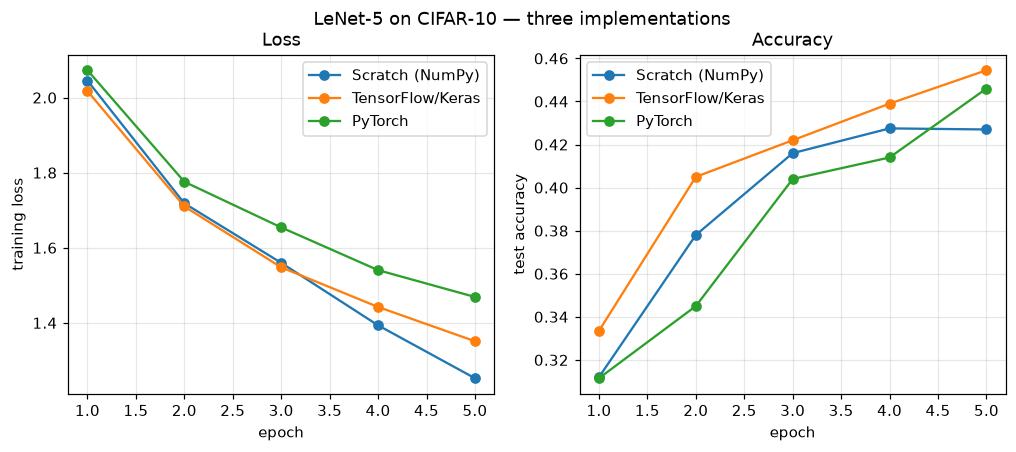

In [17]:
U.plot_history({r.framework: r.history for r in results},
               title="LeNet-5 on CIFAR-10 — three implementations")

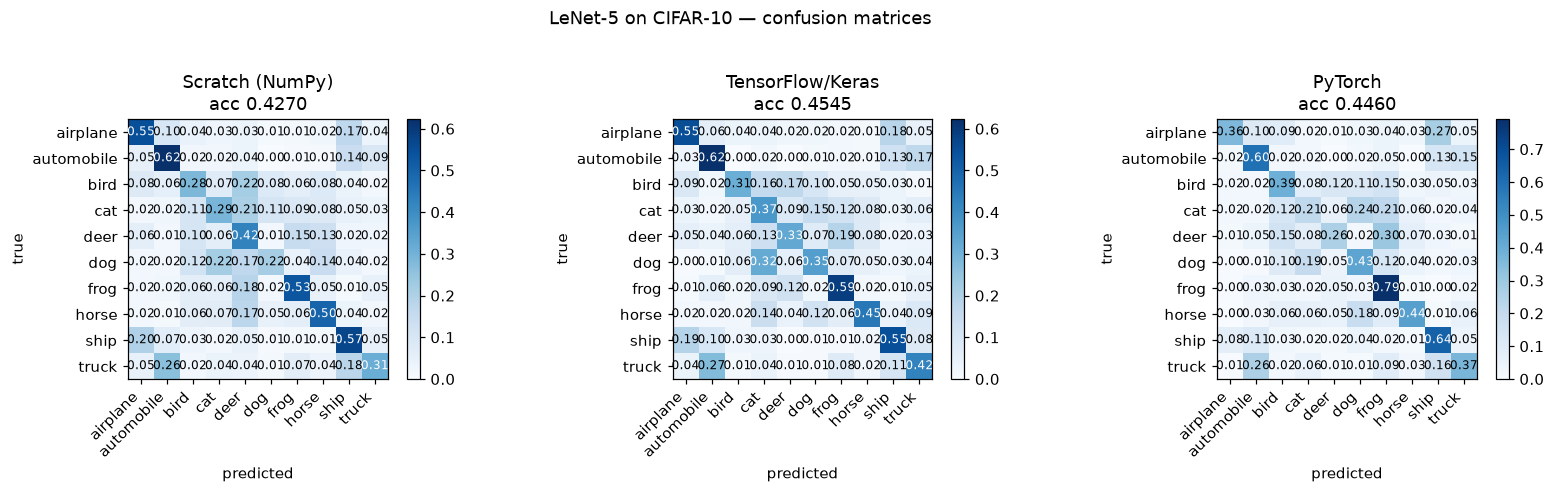

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
for ax, r in zip(axes, results):
    U.plot_confusion(np.array(r.confusion), CLASSES,
                     title=f"{r.framework}\nacc {r.test_accuracy:.4f}", ax=ax)
fig.suptitle("LeNet-5 on CIFAR-10 — confusion matrices", y=1.04)
plt.tight_layout(); plt.show()

---

## 7. Full-data reference runs

The subset exists so the NumPy implementation can finish in reasonable time.
PyTorch and Keras have no such constraint, so both are retrained on the full
50,000 training images for the same five epochs.

In [19]:
Xtr_f, ytr_f, Xte_f, yte_f, _ = U.load_cifar10(verbose=True)

full_results = []

# --- PyTorch, full data ---
U.set_seed(U.SEED)
torch_full = LeNet5(C, N_CLASSES).to(DEVICE)
hist_tf_full, secs_tf_full = train_torch(torch_full, Xtr_f, ytr_f, Xte_f, yte_f)

torch_full.eval()
with torch.no_grad():
    preds = []
    Xte_ft = torch.tensor(Xte_f).to(DEVICE)
    for i in range(0, len(Xte_ft), 1024):
        preds.append(torch_full(Xte_ft[i:i + 1024]).argmax(1).cpu().numpy())
    pred_full_torch = np.concatenate(preds)

m = U.evaluate(yte_f, pred_full_torch, N_CLASSES)
full_results.append(U.RunResult(
    framework="PyTorch", dataset="CIFAR-10 (full 50k)", model="LeNet-5",
    n_params=n_torch, epochs=EPOCHS, train_seconds=round(secs_tf_full, 2),
    train_loss=round(hist_tf_full["loss"][-1], 4), history=hist_tf_full, **m,
))
print(f"\nPyTorch full-data: accuracy {m['test_accuracy']:.4f}  macro-F1 {m['f1_macro']:.4f}")

CIFAR-10: train (50000, 3, 32, 32) / test (10000, 3, 32, 32), 10 classes


epoch 1/5  loss 1.6024  test_acc 0.4987


epoch 2/5  loss 1.3127  test_acc 0.5559


epoch 3/5  loss 1.1895  test_acc 0.5833


epoch 4/5  loss 1.1075  test_acc 0.5904


epoch 5/5  loss 1.0453  test_acc 0.6075

PyTorch full-data: accuracy 0.6075  macro-F1 0.6070


In [20]:
# --- Keras, full data ---
U.set_seed(U.SEED)
keras_full = build_keras_lenet("lenet5_full")
keras_full.compile(optimizer=keras.optimizers.Adam(learning_rate=LR),
                   loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
                   metrics=["accuracy"])

with U.Timer() as t_kf:
    hkf = keras_full.fit(np.transpose(Xtr_f, (0, 2, 3, 1)), ytr_f,
                         validation_data=(np.transpose(Xte_f, (0, 2, 3, 1)), yte_f),
                         epochs=EPOCHS, batch_size=BATCH_SIZE, verbose=2)

pred_full_keras = keras_full.predict(np.transpose(Xte_f, (0, 2, 3, 1)),
                                     batch_size=512, verbose=0).argmax(axis=1)
m = U.evaluate(yte_f, pred_full_keras, N_CLASSES)
full_results.append(U.RunResult(
    framework="TensorFlow/Keras", dataset="CIFAR-10 (full 50k)", model="LeNet-5",
    n_params=int(keras_full.count_params()), epochs=EPOCHS, train_seconds=round(t_kf.seconds, 2),
    train_loss=round(float(hkf.history["loss"][-1]), 4),
    history={"loss": [float(v) for v in hkf.history["loss"]],
             "val_acc": [float(v) for v in hkf.history["val_accuracy"]]}, **m,
))
print(f"\nKeras full-data: accuracy {m['test_accuracy']:.4f}  macro-F1 {m['f1_macro']:.4f}")

Epoch 1/5


782/782 - 7s - 9ms/step - accuracy: 0.4348 - loss: 1.5603 - val_accuracy: 0.5132 - val_loss: 1.3506


Epoch 2/5


782/782 - 5s - 7ms/step - accuracy: 0.5447 - loss: 1.2764 - val_accuracy: 0.5643 - val_loss: 1.2263


Epoch 3/5


...

Epoch 4/5


782/782 - 6s - 7ms/step - accuracy: 0.6202 - loss: 1.0788 - val_accuracy: 0.5947 - val_loss: 1.1558


Epoch 5/5


782/782 - 5s - 7ms/step - accuracy: 0.6447 - loss: 1.0131 - val_accuracy: 0.6032 - val_loss: 1.1379



Keras full-data: accuracy 0.6032  macro-F1 0.5985


In [21]:
display(U.results_table(results + full_results))

,framework,dataset,model,n_params,epochs,train_seconds,train_loss,test_accuracy,precision_macro,recall_macro,f1_macro
0,Scratch (NumPy),CIFAR-10 (5k subset),LeNet-5,62006,5,28.71,1.2525,0.4270,0.4314,0.4294,0.4216
1,TensorFlow/Keras,CIFAR-10 (5k subset),LeNet-5,62006,5,4.72,1.3510,0.4545,0.4601,0.4550,0.4528
2,PyTorch,CIFAR-10 (5k subset),LeNet-5,62006,5,1.54,1.4689,0.4460,0.4588,0.4480,0.4363
3,PyTorch,CIFAR-10 (full 50k),LeNet-5,62006,5,30.88,1.0453,0.6075,0.6150,0.6075,0.6070
4,TensorFlow/Keras,CIFAR-10 (full 50k),LeNet-5,62006,5,29.27,1.0131,0.6032,0.6018,0.6032,0.5985


---

## 8. LeNet-5 versus the baseline architecture

This is the section the notebook exists for. `results/03_cifar10.json` holds the
results of `SmallCNN` trained on identical data with identical
hyperparameters, so the two are directly comparable.

In [22]:
with open("results/03_cifar10.json") as f:
    baseline = json.load(f)

base_rows = baseline["results"] + baseline.get("full_results", [])
lenet_rows = [r.__dict__ for r in results + full_results]

cmp = pd.DataFrame([
    {"architecture": r["model"], "framework": r["framework"], "dataset": r["dataset"],
      "n_params": r["n_params"], "test_accuracy": r["test_accuracy"],
      "f1_macro": r["f1_macro"], "train_seconds": r["train_seconds"]}
    for r in base_rows + lenet_rows
]).sort_values(["dataset", "architecture", "framework"]).reset_index(drop=True)

display(cmp.round(4))

,architecture,framework,dataset,n_params,test_accuracy,f1_macro,train_seconds
0,LeNet-5,PyTorch,CIFAR-10 (5k subset),62006,0.4460,0.4363,1.54
1,LeNet-5,Scratch (NumPy),CIFAR-10 (5k subset),62006,0.4270,0.4216,28.71
2,LeNet-5,TensorFlow/Keras,CIFAR-10 (5k subset),62006,0.4545,0.4528,4.72
3,SmallCNN,PyTorch,CIFAR-10 (5k subset),545098,0.5310,0.5268,2.84
4,SmallCNN,Scratch (NumPy),CIFAR-10 (5k subset),545098,0.5055,0.5032,83.02
5,SmallCNN,TensorFlow/Keras,CIFAR-10 (5k subset),545098,0.5485,0.5452,9.93
6,LeNet-5,PyTorch,CIFAR-10 (full 50k),62006,0.6075,0.6070,30.88
7,LeNet-5,TensorFlow/Keras,CIFAR-10 (full 50k),62006,0.6032,0.5985,29.27
8,SmallCNN,PyTorch,CIFAR-10 (full 50k),545098,0.7190,0.7178,34.74
9,SmallCNN,TensorFlow/Keras,CIFAR-10 (full 50k),545098,0.7043,0.6990,75.94


In [23]:
# Head-to-head on each (dataset, framework) pair present in both runs.
pivot = (cmp.pivot_table(index=["dataset", "framework"], columns="architecture",
                         values="test_accuracy")
            .dropna())
pivot["delta (LeNet - baseline)"] = pivot["LeNet-5"] - pivot["SmallCNN"]
display(pivot.round(4))

mean_delta = pivot["delta (LeNet - baseline)"].mean()
print(f"\nmean accuracy delta across matched runs: {mean_delta:+.4f} "
      f"({mean_delta*100:+.2f} points)")

params_base = cmp[cmp["architecture"] == "SmallCNN"]["n_params"].iloc[0]
params_lenet = cmp[cmp["architecture"] == "LeNet-5"]["n_params"].iloc[0]
print(f"parameters: LeNet-5 {params_lenet:,} vs SmallCNN {params_base:,} "
      f"({params_lenet/params_base:.2f}x)")

architecture                           LeNet-5  SmallCNN  \
dataset              framework                             
CIFAR-10 (5k subset) PyTorch            0.4460    0.5310   
                     Scratch (NumPy)    0.4270    0.5055   
                     TensorFlow/Keras   0.4545    0.5485   
CIFAR-10 (full 50k)  PyTorch            0.6075    0.7190   
                     TensorFlow/Keras   0.6032    0.7043   

architecture                           delta (LeNet - baseline)  
dataset              framework                                   
CIFAR-10 (5k subset) PyTorch                            -0.0850  
                     Scratch (NumPy)                    -0.0785  
                     TensorFlow/Keras                   -0.0940  
CIFAR-10 (full 50k)  PyTorch                            -0.1115  
                     TensorFlow/Keras                   -0.1011


mean accuracy delta across matched runs: -0.0940 (-9.40 points)
parameters: LeNet-5 62,006 vs SmallCNN 545,098 (0.11x)


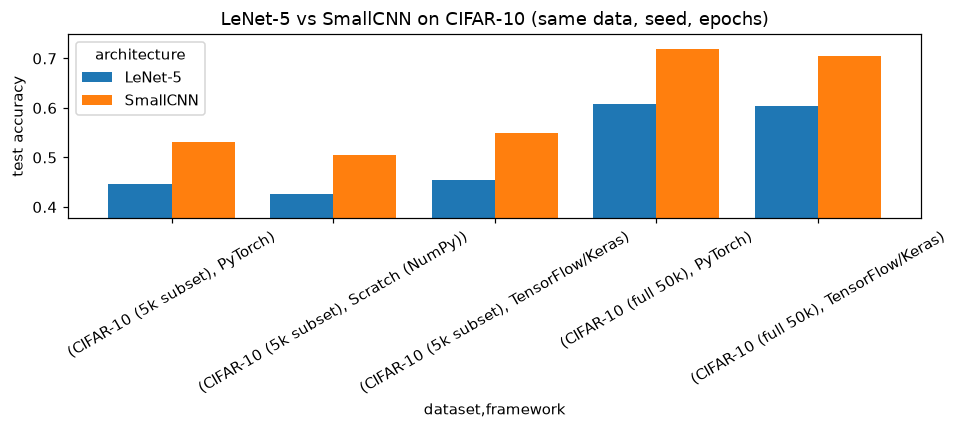

In [24]:
fig, ax = plt.subplots(figsize=(9, 4))
plot_df = pivot.drop(columns="delta (LeNet - baseline)")
plot_df.plot(kind="bar", ax=ax, width=0.78)
ax.set_ylabel("test accuracy")
ax.set_title("LeNet-5 vs SmallCNN on CIFAR-10 (same data, seed, epochs)")
ax.set_ylim(plot_df.values.min() - 0.05, min(1.0, plot_df.values.max() + 0.03))
ax.legend(title="architecture")
ax.tick_params(axis="x", rotation=30)
plt.tight_layout(); plt.show()

---

## 9. Where each component lives

In [25]:
component_table = pd.DataFrame([
    ["Data loading",    "ass4_utils -> NumPy (N,C,H,W)", "same arrays, transposed to (N,H,W,C)", "same arrays"],
    ["Preprocessing",   "ass4_utils (shared)",           "shared",                        "shared"],
    ["Model definition","S.Sequential([...])",           "keras.Sequential([...])",       "nn.Module (LeNet5)"],
    ["C1 / C3 conv",    "S.Conv2D(k=5) im2col+matmul",   "keras.layers.Conv2D(5)",        "nn.Conv2d(5)"],
    ["Activation",      "S.ReLU (mask multiply)",        "activation='relu'",             "nn.ReLU"],
    ["S2 / S4 pooling", "S.MaxPool2D (argmax routing)",  "keras.layers.MaxPooling2D",     "nn.MaxPool2d"],
    ["Flatten",         "S.Flatten (reshape)",           "keras.layers.Flatten",          "nn.Flatten"],
    ["F5 / F6 / output","S.Dense (x@W+b)",               "keras.layers.Dense",            "nn.Linear"],
    ["Loss",            "S.SoftmaxCrossEntropy",         "SparseCategoricalCrossentropy", "nn.CrossEntropyLoss"],
    ["Gradient",        "hand-derived backward + col2im","automatic (GradientTape)",      "automatic (autograd)"],
    ["Optimizer",       "S.Adam (written out)",          "keras.optimizers.Adam",         "torch.optim.Adam"],
    ["Training loop",   "explicit for-loop",             "model.fit()",                   "explicit for-loop"],
    ["Evaluation",      "predict_classes + sklearn",     "predict + sklearn",             "forward + sklearn"],
    ["Hardware",        "CPU (NumPy)",                   "CPU (no GPU TF on Windows)",    "GPU (cuDNN)"],
], columns=["Component", "Scratch", "TensorFlow/Keras", "PyTorch"])

display(component_table)

,Component,Scratch,TensorFlow/Keras,PyTorch
0,Data loading,"ass4_utils -> NumPy (N,C,H,W)","same arrays, transposed to (N,H,W,C)",same arrays
1,Preprocessing,ass4_utils (shared),shared,shared
2,Model definition,S.Sequential([...]),keras.Sequential([...]),nn.Module (LeNet5)
3,C1 / C3 conv,S.Conv2D(k=5) im2col+matmul,keras.layers.Conv2D(5),nn.Conv2d(5)
4,Activation,S.ReLU (mask multiply),activation='relu',nn.ReLU
5,S2 / S4 pooling,S.MaxPool2D (argmax routing),keras.layers.MaxPooling2D,nn.MaxPool2d
6,Flatten,S.Flatten (reshape),keras.layers.Flatten,nn.Flatten
7,F5 / F6 / output,S.Dense (x@W+b),keras.layers.Dense,nn.Linear
8,Loss,S.SoftmaxCrossEntropy,SparseCategoricalCrossentropy,nn.CrossEntropyLoss
9,Gradient,hand-derived backward + col2im,automatic (GradientTape),automatic (autograd)


In [26]:
os.makedirs("results", exist_ok=True)
with open("results/07_cifar10_lenet.json", "w") as f:
    json.dump({"meta": {k: v for k, v in meta.items()},
               "results": [r.__dict__ for r in results],
               "full_results": [r.__dict__ for r in full_results],
               "component_table": component_table.to_dict(orient="records"),
               "baseline_comparison": pivot.reset_index().to_dict(orient="records")},
              f, indent=2, default=str)
print("saved results/07_cifar10_lenet.json")

saved results/07_cifar10_lenet.json


---

## 10. What this notebook shows

This is where holding the architecture fixed pays off. LeNet-5 was built for
32×32 grayscale digits; CIFAR-10 is 32×32 colour photographs. The input
dimensions match exactly, the difficulty does not.

Section 8 quantifies the cost. LeNet-5 carries roughly one ninth the parameters
of `SmallCNN`, and almost all of what it does have sits in the classifier head
rather than the feature extractor — C1 and C3 together hold under 3k weights.
Six feature maps is not enough visual vocabulary for ten object classes shot at
varying pose, lighting and background.

The lesson is not that LeNet-5 is a bad architecture. It is that **architecture
capacity has to match dataset difficulty**. The same network that is entirely
adequate for digits is undersized for natural images, and no amount of training
time fixes a representation bottleneck this narrow. Widening the feature maps —
which is exactly what `SmallCNN` does with 32 and 64 channels — is what closes
the gap.

Compare with `04_compare.ipynb`, where M1 → M4 hold the parameter budget roughly
constant and change the *mechanisms* instead (BatchNorm, residual connections,
SE attention). Those two axes — capacity and mechanism — are independent ways to
improve a CNN.